# EEP 567 Lab 3: Breaking CAPTCHAs with Convolutional Neural Network in PyTorch
In lab 3, we are going to work on a seemingly impossible task: automatically break CAPTCHAs with deep learning! Originally, CAPTCHA stands for "Completely Automated Public Turing test to tell Computers and Humans Apart", and traditional CAPCTHAs serve as a great tool to stop spam bots and malicious crawlers. Today, as we have made huge progress in computer vision and deep learning, these CAPCTHAs are no longer unbreakable by computers. Now let's prove the correctness of the claim by ourselves!

As usual, please check if the helper library, `lab_3_helpers.py` and the extracted dataset directory, `captcha-images` exist under the same directory. Then, create a standalone environment for all dependencies of this lab:

In [1]:
%pip install matplotlib scikit-learn "opencv-python>4" imutils tqdm

# If using Anaconda / Miniconda, install PyTorch with:
#%conda install conda-forge::pytorch-gpu # (CPU and GPU support)
#%conda install conda-forge::pytorch # (CPU-only support)

# If using Pip, install PyTorch with:
%pip install torch
# When installing PyTorch with GPU support, refer to https://pytorch.org/get-started/locally/
# if your CUDA version differs from the default CUDA version of the current version PyTorch package.

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------- ----------------- 22.5/40.2 MB 123.7 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 127.8 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 92.7 MB/s eta 0:00:00
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25855 sha256=76ca9b2a553f50df9a6ef4e18453a7f6399abb417f54f149a791009fa6bf2e31
  Stored in directory: c:\users\sungpochang\appdata\local\pip\cache\wheels\69\2c\66\f966db29490794305257ac3abfe71d4f963f5fc75ba0eb8eb7
Successfully built imutils

   -------------------- ------------------- 1/2 [opencv-python]
   -------------------- ------------------- 1/2 [opencv-python]
   -------------------- ------------------- 1/2 [opencv-python]
   -------------------- ------------------- 1/2 [opencv-python]
   ---------------

  DEPRECATION: Building 'imutils' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'imutils'. Discussion can be found at https://github.com/pypa/pip/issues/6334


   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ------- ------------------------------- 21.5/113.8 MB 121.6 MB/s eta 0:00:01
   --------------- ----------------------- 44.0/113.8 MB 112.7 MB/s eta 0:00:01
   ----------------------- --------------- 68.7/113.8 MB 115.3 MB/s eta 0:00:01
   --------------------------------- ----- 99.1/113.8 MB 122.1 MB/s eta 0:00:01
   -------------------------------------  113.5/113.8 MB 125.1 MB/s eta 0:00:01
   -------------------------------------- 113.8/113.8 MB 109.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Next, we import some of the tools needed before starting:

In [2]:
import os, pickle, glob, math
from pprint import pprint

import cv2
import numpy as np
import imutils
from imutils import paths
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Import helper functions from the lab utilities module
from lab_3_helpers import *

# Preprocessing
## Ground Truth Characters Extraction
As usual, we will start pre-processing stage by loading CAPTCHA images into the memory:

In [4]:
# Dataset images folder
CAPTCHA_IMAGE_FOLDER = "./captcha-images"

# List of all the captcha images we need to process
captcha_image_paths = list(paths.list_images(CAPTCHA_IMAGE_FOLDER))
# Review image paths
pprint(captcha_image_paths[:10])

['./captcha-images\\2A2X.png',
 './captcha-images\\2A5R.png',
 './captcha-images\\2A5Z.png',
 './captcha-images\\2A98.png',
 './captcha-images\\2A9N.png',
 './captcha-images\\2AD9.png',
 './captcha-images\\2AEF.png',
 './captcha-images\\2APC.png',
 './captcha-images\\2AQ7.png',
 './captcha-images\\2AX2.png']


Note that for each image, its file name (without extension) happens to be its corresponding CAPTCHA text. Thus, we extract file names for all CAPTCHA images and save them as labels for future use:

In [5]:
def extract_captcha_text(image_path):
    """ Extract correct CAPTCHA texts from file name of images. """
    # Extract file name of image from its path
    # e.g. "./captcha-images/2A2X.png" -> "2A2X.png"
    image_file_name = os.path.basename(image_path)
    # Extract base name of image, omitting file extension
    # e.g. "2A2X.png" -> "2A2X"
    return os.path.splitext(image_file_name)[0]

captcha_texts = [extract_captcha_text(image_path) for image_path in captcha_image_paths]
# Review extraction results
pprint(captcha_texts[:10])

['2A2X', '2A5R', '2A5Z', '2A98', '2A9N', '2AD9', '2AEF', '2APC', '2AQ7', '2AX2']


## Loading and Transforming Images
For the feature extraction stage, we are going to extract individual characters from these CAPTCHAs. This is done by looking for contours (bounding boxes) around characters, then cropping the CAPTCHAs such as only the contour areas are preserved. We begin feature extraction by loading and transforming images:

Figure(2000x500)


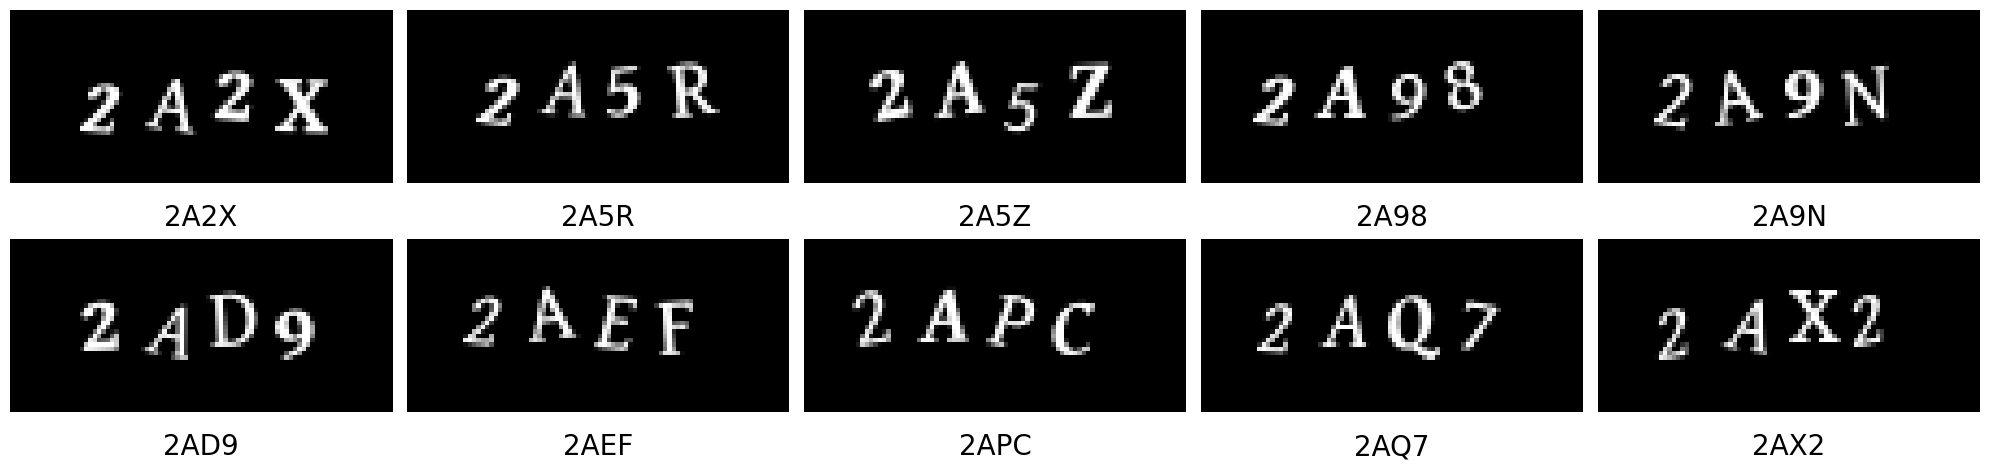

In [8]:
def load_transform_image(image_path):
    """ Load and transform image into grayscale. """
    # Load image from file
    image = cv2.imread(image_path)
    
    # Convert image from BGR to grayscale
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Add extra padding (8px) around the image to provide context for character detection
    image_padded = cv2.copyMakeBorder(image_gray, 8, 8, 8, 8, cv2.BORDER_REPLICATE)

    return image_padded

captcha_images = [load_transform_image(image_path) for image_path in captcha_image_paths]
# Review loaded CAPTCHAs
print_images(
    captcha_images[:10], n_rows=2, texts=captcha_texts[:10]
)

Next, we will split our dataset into train-validation set and test set. The former set will be used for training and validation in deep character classification model, while the latter will be used for testing our CAPTCHA recognition pipline end-to-end:

In [7]:
# Train-validation-test split seed
TVT_SPLIT_SEED = 31528476

# Perform split on CAPTCHA images as well as labels
captcha_images_tv, captcha_images_test, captcha_texts_tv, captcha_texts_test = train_test_split(
    captcha_images, captcha_texts, test_size=0.2, random_state=TVT_SPLIT_SEED
)

print("Train-validation:", len(captcha_texts_tv))
print("Test:", len(captcha_texts_test))

Train-validation: 908
Test: 228


## Bounding Box Extraction
It's now time to perform the most important feature extraction step: finding contours and extracting characters. Contours can be explained simply as a curve joining all the continuous points (along the boundary), having same color or intensity. It is useful for shape analysis and object detection and recognition. For our task however, we are **more interested in the bounding boxes around characters**, since these are the part of images we will be used for character classification:

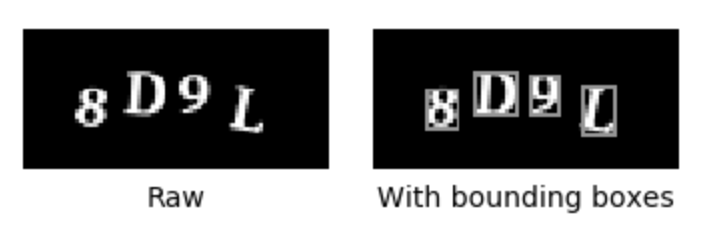

Here are the steps we are going to perform:

* Find contours around characters in CAPTCHAs.
* Get the position and size for each corresponding bounding box.
* If a bounding box is too wide (width-to-height ratio larger than 1.25), chances are that we have bounded two letters in a single bounding box. In this case, split the bounding box vertically from the center into two.
* Store all bounding boxes for the CAPTCHA.
* If there aren't 4 bounding boxes for the CAPTCHA, ignore it since our character extraction process must have run into problems in this case.
* Sort the bounding boxes by their X coordinates, so that they match the order corresponding letters occur.
* For each bounding box, extract corresponding region of the image, and store it as an instance of corresponding character at `${CHAR_IMAGE_FOLDER}/{letter}/{count}.png`.

After these steps, we have transformed CAPTCHA images into images of single character. This simplifies our task since now our model only needs to deal with classification (from character image to character itself) rather than also dealing with detection (finding and extracting charatcers).

In [9]:
# Character images folder template
CHAR_IMAGE_FOLDER = f"./char-images-{TVT_SPLIT_SEED}"

def extract_chars(image):
    """ Find contours and extract characters inside each CAPTCHA. """
    # Apply binary threshold with inversion to make text white on black background
    image_bw = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    # Find contours (continuous blobs of pixels) in the image
    contours = cv2.findContours(image_bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    char_regions = []
    # Loop through each contour to extract character bounding boxes
    for contour in contours:
        # Get the bounding rectangle that contains the contour
        x, y, w, h = cv2.boundingRect(contour)

        # Compare the width and height of the bounding box,
        # detect if there are letters conjoined into one chunk
        if w / h > 1.25:
            # Bounding box is too wide for a single character
            # Split it in half into two letter regions
            half_width = int(w / 2)
            char_regions.append((x, y, half_width, h))
            char_regions.append((x + half_width, y, half_width, h))
        else:
            # Only a single letter in contour
            char_regions.append((x, y, w, h))

    # Ignore image if less or more than 4 regions detected (since all CAPTCHAs have 4 characters)
    if len(char_regions)!=4:
        return None
    # Sort regions by their X coordinates to match character order
    char_regions.sort(key=lambda x: x[0])

    # Character images to return
    char_images = []
    # Save each character as a single image
    for x, y, w, h in char_regions:
        # Extract character from image with 2px margin for better context
        char_image = image[y - 2:y + h + 2, x - 2:x + w + 2]
        # Save character images
        char_images.append(char_image)      

    # Return character images
    return char_images

def save_chars(char_images, captcha_text, save_dir, char_counts):
    """ Save character images to directory organized by character. """
    for char_image, char in zip(char_images, captcha_text):
        # Get the folder to save the image in (one folder per character)
        save_path = os.path.join(save_dir, char)
        os.makedirs(save_path, exist_ok=True)
        
        # Write character image to file with sequential numbering
        char_count = char_counts.get(char, 1)
        char_image_path = os.path.join(save_path, f"{char_count}.png")
        cv2.imwrite(char_image_path, char_image)
        
        # Update count for this character
        char_counts[char] = char_count+1

# Force character extraction even if results are already available
FORCE_EXTRACT_CHAR = False      

char_counts = {}
# Extract and save images for characters from training-validation set
if FORCE_EXTRACT_CHAR or not os.path.exists(CHAR_IMAGE_FOLDER):
    for captcha_image, captcha_text in zip(captcha_images_tv, captcha_texts_tv):
        # Extract character images from CAPTCHA
        char_images = extract_chars(captcha_image)
        # Skip if extraction failed
        if char_images is None:
            continue
        # Save character images
        save_chars(char_images, captcha_text, CHAR_IMAGE_FOLDER, char_counts)

## Label Encoding
During the training stage, we are going to load character images from previous stages as features and generate corresponding labels from their path. We will then rescale features, encode labels as numerical indices, and save the label encoder to an external file.


In [10]:
# Path of occurred characters (labels)
LABELS_PATH = "./labels.pkl"

def make_feature(image):
    """ Process character image and turn it into feature. """
    # Resize character to 20x20 pixels for consistent input size
    image_resized = resize_to_fit(image, 20, 20)
    # Add extra dimension as the only channel
    # (Note: The channel dimension comes before the width and height dimension for PyTorch!)
    feature = image_resized[None, ...]
    
    return feature

def make_feature_label(image_path):
    """ Load character image and make feature-label pair from image path. """
    # Load image in grayscale and make feature
    feature = make_feature(cv2.imread(image_path, cv2.COLOR_BGR2GRAY))
    # Extract label based on the directory the image is in (directory name = character)
    label = image_path.split(os.path.sep)[-2]
    
    return feature, label

# Make features and labels from all character image paths
features_tv, labels_tv = unzip((
    make_feature_label(image_path) for image_path in paths.list_images(CHAR_IMAGE_FOLDER)
))

# Scale raw pixel values into range [0, 1] for better neural network training
features_tv = np.array(features_tv, dtype=np.float32)/255
# Convert character labels into numerical label indices
le = LabelEncoder()
label_indices_tv = le.fit_transform(labels_tv)
# Number of character classes
n_classes = len(le.classes_)

# Further split the training data into training and validation set
X_train, X_vali, y_train, y_vali = train_test_split(
    features_tv, label_indices_tv, test_size=0.25, random_state=955996
)
# Save label encoder mapping from labels to indices for later use in predictions
with open(LABELS_PATH, "wb") as f:
    pickle.dump(le, f)

# Training
Next, we build a Convolutional Neural Network (CNN) as our classification model with PyTorch. Below is a demonstration of the structure of the neural network:

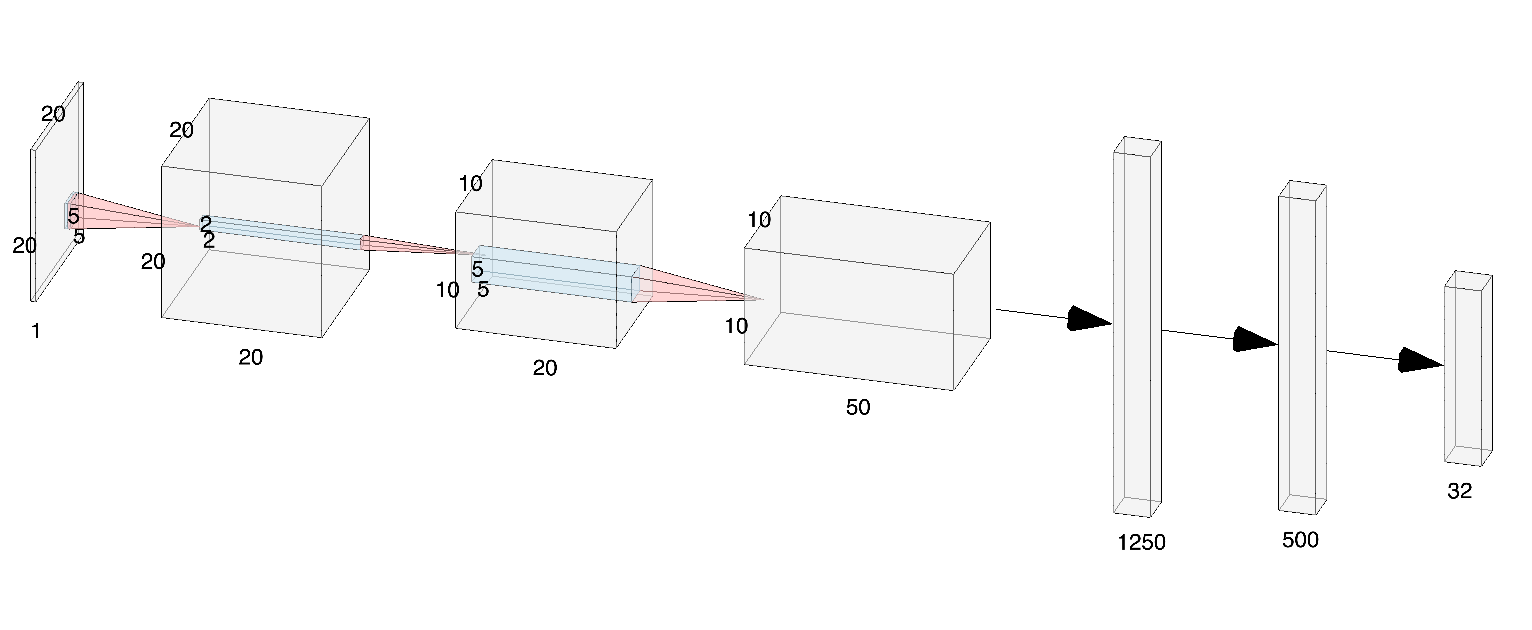

After building the neural network, we train it and save its weights.

## Understanding the PyTorch Training Loop

Unlike the high-level Keras API where you simply call `model.fit()`, PyTorch requires us to implement the training loop explicitly. This gives us more control but requires more code. Here's what happens in each part:

1. **Forward Pass**: We pass a batch of images through the model to get predictions (logits). The model computes the output by applying all layers sequentially.

2. **Loss Computation**: We calculate the cross-entropy loss, which measures how wrong our predictions are compared to the ground truth labels. Lower loss means better predictions.

3. **Backward Pass**: We call `.backward()` to compute gradients for all model parameters. These gradients tell us in which direction to adjust each parameter to reduce the loss.

4. **Optimizer Step**: We call `optimizer.step()` to update all model parameters in the direction opposite to the gradients (this is gradient descent). The learning rate controls how large each update is.

5. **Gradient Clearing**: We call `optimizer.zero_grad()` to clear the gradients, otherwise they would accumulate in the next iteration.

6. **Validation**: After each epoch, we evaluate the model on the validation set (without updating parameters) to monitor if the model is overfitting or generalizing well.

This explicit loop structure is fundamental to PyTorch and gives you complete flexibility in modifying the training process, such as implementing custom loss functions, changing optimization strategies, or adding regularization techniques.

In [13]:
import torch
from torch import nn, optim
from torch.nn import functional as f
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm

# Batch size for training
BATCH_SIZE = 32
# Number of training epochs
N_EPOCHS = 20

# Path of model weights file
MODEL_WEIGHTS_PATH = "./captcha-model-weights.pt"
# Force training even if weights are already available
FORCE_TRAINING = True

# Detect best PyTorch device to run the model
# (Prefer GPU devices such as CUDA or MPS, then fall back to CPU as last resort)
torch_device = get_torch_device()

# Build a feed-forward convolutional neural network model
model = nn.Sequential(
    # [ TODO ]
    # Complete the neural network shown in the above figure and the following instructions.
    #
    # First convolution block: (*, 1, 20, 20) -Conv2d-> (*, 20, 20, 20) -ReLU-> (*, 20, 20, 20) -MaxPool2d-> (*, 20, 10, 10)
    # 1) Convolution layer: 1 input channel, 20 output channels, 5x5 kernel, padded to maintain same shape
    # 2) ReLU activation layer to introduce non-linearity
    # 3) Max pooling layer: 2x2 kernel to reduce spatial dimensions
    nn.Conv2d(1, 20, (5,5), padding="same"),
    nn.ReLU(),
    nn.MaxPool2d((2,2)),
    
    # Second convolution block: (*, 20, 10, 10) -Conv2d-> (*, 50, 10, 10) -ReLU-> (*, 50, 10, 10) -MaxPool2d-> (*, 50, 5, 5)
    # 1) Convolution layer: 20 input channels, 50 output channels, 5x5 kernel, padded to maintain same shape
    # 2) ReLU activation layer to introduce non-linearity
    # 3) Max pooling layer: 2x2 kernel to reduce spatial dimensions
    nn.Conv2d(20, 50, (5,5), padding="same"),
    nn.ReLU(),
    nn.MaxPool2d((2,2)),
    
    # Flatten layer to reshape features to 1D: (*, 50, 5, 5) -Flatten-> (*, 1250)
    nn.Flatten(),
    # First fully-connected (linear) layer: (*, 1250) -Linear-> (*, 500) -ReLU-> (*, 500)
    # Reduces feature dimensionality before final classification
    nn.Linear(1250, 500),
    nn.ReLU(),
    # Last fully-connected (linear) layer: (*, 500) -Linear-> (*, n_classes)
    # Outputs logits for each character class; will be converted to probabilities via Softmax
    # (Important note: do NOT add a Softmax layer here, as PyTorch's cross_entropy loss function expects raw logits)
    nn.Linear(500, n_classes),
)
# Move model to target device
model = model.to(torch_device)
# Build an optimizer (AdamW) with all parameters of our model
# AdamW is an adaptive learning rate optimizer that works well for deep learning tasks
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Build training and validation datasets from tensors
dataset_train = TensorDataset(torch.as_tensor(X_train), torch.as_tensor(y_train))
dataset_vali = TensorDataset(torch.as_tensor(X_vali), torch.as_tensor(y_vali))
# Build training and validation data loaders for batch processing
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_vali = DataLoader(dataset_vali, batch_size=BATCH_SIZE)

print("Model structure:")
print(model)
print()

if FORCE_TRAINING or not os.path.exists(MODEL_WEIGHTS_PATH):
    # Training loop
    print("Starting training...")
    for i in range(N_EPOCHS):
        # In every epoch, do training first ...
        loss_train = 0.
    
        print(f"Starting training epoch {i+1}/{N_EPOCHS}...")
        # [ TODO ]
        # Complete the training loop by filling in the missing parts below:
        #
        # 1) Forward pass: run the model on batch
        # 2) Compute cross entropy loss (combines softmax and negative log likelihood)
        # 3) Backward pass: compute gradients for all model parameters
        # 4) Take an optimizer step to update model parameters
        # 5) Clear gradients for next iteration
        # 6) Accumulate cross entropy loss to collect statistics
        #    (Hint: Detach loss tensor before accumulation)
        #    (Hint: Move tensors to CPU for accumulation)
        for X_batch, y_batch in tqdm(loader_train):
            # Move tensors to target device
            X_batch = X_batch.to(torch_device)
            y_batch = y_batch.to(torch_device)
            # 1) Forward pass
            outputs = model(X_batch)
            
            # 2) Compute cross entropy loss
            loss = f.cross_entropy(outputs, y_batch)
            
            # 3) Backward pass
            loss.backward()
            
            # 4) Optimizer step
            optimizer.step()
            
            # 5) Clear gradients for next iteration
            optimizer.zero_grad()
            
            # 6) Accumulate loss
            loss_train += loss.detach().cpu()
                
        loss_train /= len(loader_train)
        print(f"Training loss of epoch {i+1}/{N_EPOCHS}: {loss_train.item()}")
    
        # Then evaluate the model on validation set
        loss_vali = 0.
    
        # Put model in validation/evaluation mode (disables dropout, etc.)
        model.eval()
    
        print(f"Starting validation epoch {i+1}/{N_EPOCHS}...")
        # [ TODO ]
        # Complete the validation loop by filling in the missing parts below:
        #
        # 1) Forward pass: run the model on batch
        # 2) Compute cross entropy loss
        # 3) Accumulate cross entropy loss to collect statistics
        #    (Hint: Move tensors to CPU for accumulation)
        for X_batch, y_batch in tqdm(loader_vali):
            # Move tensors to target device
            X_batch = X_batch.to(torch_device)
            y_batch = y_batch.to(torch_device)
            
            # 1) Forward pass
            outputs = model(X_batch)
            
            # 2) Compute cross entropy loss
            loss = f.cross_entropy(outputs, y_batch)
            
            # 3) Accumulate loss
            loss_vali += loss.detach().cpu()
    
        loss_vali /= len(loader_vali)
        print(f"Validation loss of epoch {i+1}/{N_EPOCHS}: {loss_vali.item()}")
    
        # Put model back in training mode
        model.train()

    # Save model weights after training is done
    print()
    print(f"Training completed. Saving model weights to {MODEL_WEIGHTS_PATH} ...")
    torch.save(model.state_dict(), MODEL_WEIGHTS_PATH)
else:
    # Load model weights from file
    model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))

Model structure:
Sequential(
  (0): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1250, out_features=500, bias=True)
  (8): ReLU()
  (9): Linear(in_features=500, out_features=32, bias=True)
)

Starting training...
Starting training epoch 1/20...


100%|██████████████████████████████████████████████████████████████████████████████████| 84/84 [00:04<00:00, 20.46it/s]


Training loss of epoch 1/20: 3.3608829975128174
Starting validation epoch 1/20...


100%|█████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 177.76it/s]


Validation loss of epoch 1/20: 3.2442939281463623
Starting training epoch 2/20...


...

Validation loss of epoch 19/20: 0.1590309590101242
Starting training epoch 20/20...


100%|██████████████████████████████████████████████████████████████████████████████████| 84/84 [00:01<00:00, 42.33it/s]


Training loss of epoch 20/20: 0.03371686488389969
Starting validation epoch 20/20...


100%|█████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 171.78it/s]

Validation loss of epoch 20/20: 0.1525530070066452

Training completed. Saving model weights to ./captcha-model-weights.pt ...


# Evaluation
During the training part, we have validated the performance of our neural network model on images of single characters. Now it's time to test and evaluate CAPTCHAs from the beginning to the end. First, we will need to build the pipeline for CAPTCHA character prediction:

In [19]:
# Load label encoder from file so we can translate model predictions back to actual letters
with open(LABELS_PATH, "rb") as f:
    le = pickle.load(f)

# Test our complete pipeline (character extraction + classification) with the test set.
# Note: In real-world scenarios, you'd want to test with random CAPTCHAs from the wild.

# Dummy character images used as placeholder when character extraction fails
DUMMY_CHAR_IMAGES = np.zeros((4, 20, 20, 1))

# Indices of CAPTCHAs on which character extractions failed
extract_failed_indices = []
# Extracted character images from all CAPTCHAs
char_images_test = []

# Extract character images from each CAPTCHA in the test set
for i, captcha_image in enumerate(captcha_images_test):
    # Extract character images from this CAPTCHA
    char_images = extract_chars(captcha_image)
    
    if char_images:
        # Extraction successful, add the character images
        char_images_test.extend(char_images)
    # Use dummy character images as placeholder if extraction failed
    else:
        extract_failed_indices.append(i)
        char_images_test.extend(DUMMY_CHAR_IMAGES)

# Make features for character images for neural network input
features_test = [make_feature(char_image) for char_image in char_images_test]
# Scale raw pixel values into range [0, 1] to match training data
features_test = np.array(features_test, dtype=np.float32)/255

# [ TODO ]
# Complete the core evaluation steps below:
#
# 1) Convert `features_test` to PyTorch tensor, then move it onto the target `torch_device`.
# 2) Predict labels (classes) with the neural network model we just trained.
#    Notably, you should forward converted `features_test` through the neural network,
#    select the label (class) with the largest logit value,
#    and then move the results back to CPU.
# 3) Use `le`, the `LabelEncoder` we created, to convert predictions back from numerical indices
#    to actual characters.
X_test_tensor = torch.as_tensor(features_test, device=torch_device)

model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    pred_indices = torch.argmax(logits, dim=1).cpu().numpy()

preds_test = le.inverse_transform(pred_indices)

# Group all 4 characters for the same CAPTCHA (since each CAPTCHA has 4 characters)
preds_test = ["".join(chars) for chars in group_every(preds_test, 4)]
# Update result for CAPTCHAs on which extractions failed (mark with "-")
for i in extract_failed_indices:
    preds_test[i] = "-"

Now, we can compute the accuracy of our pipeline, as well as taking a look at correct and incorrect CAPTCHA text predictions:

# of test CAPTCHAs: 228
# correctly recognized: 212
Accuracy: 0.9298245614035088 

Figure(2000x500)
Figure(2000x600)


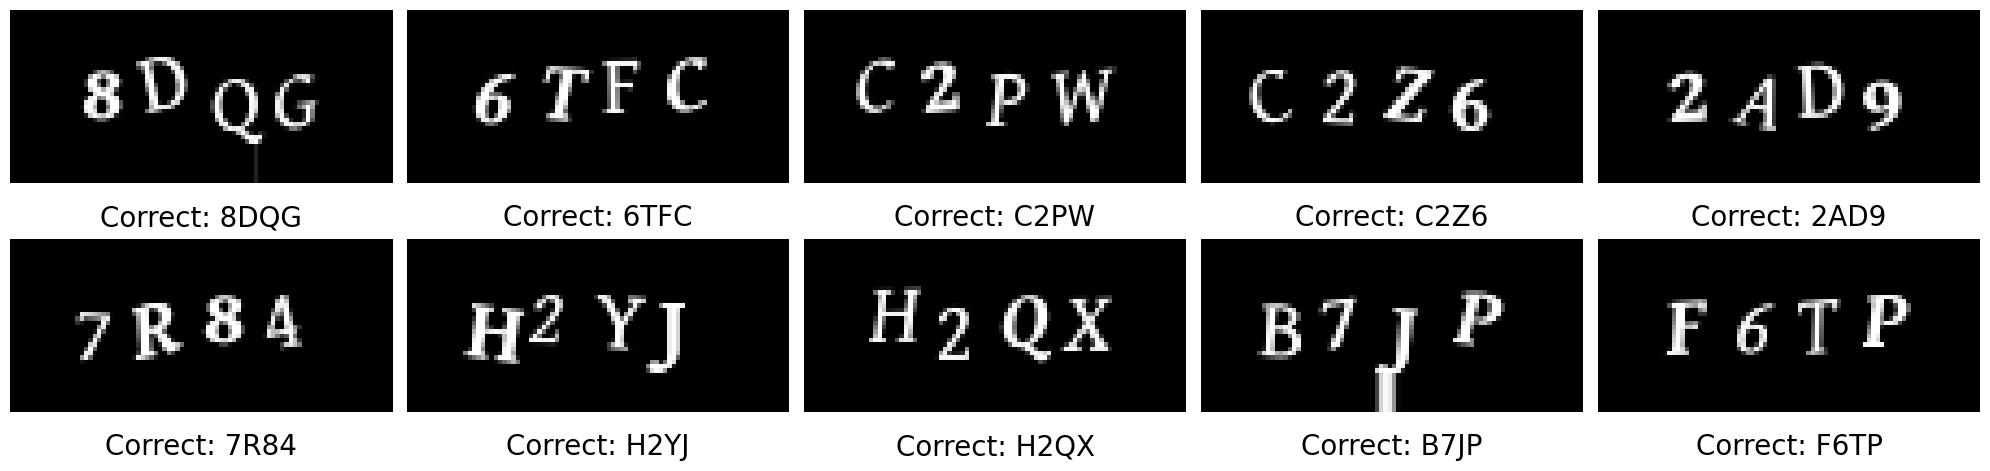

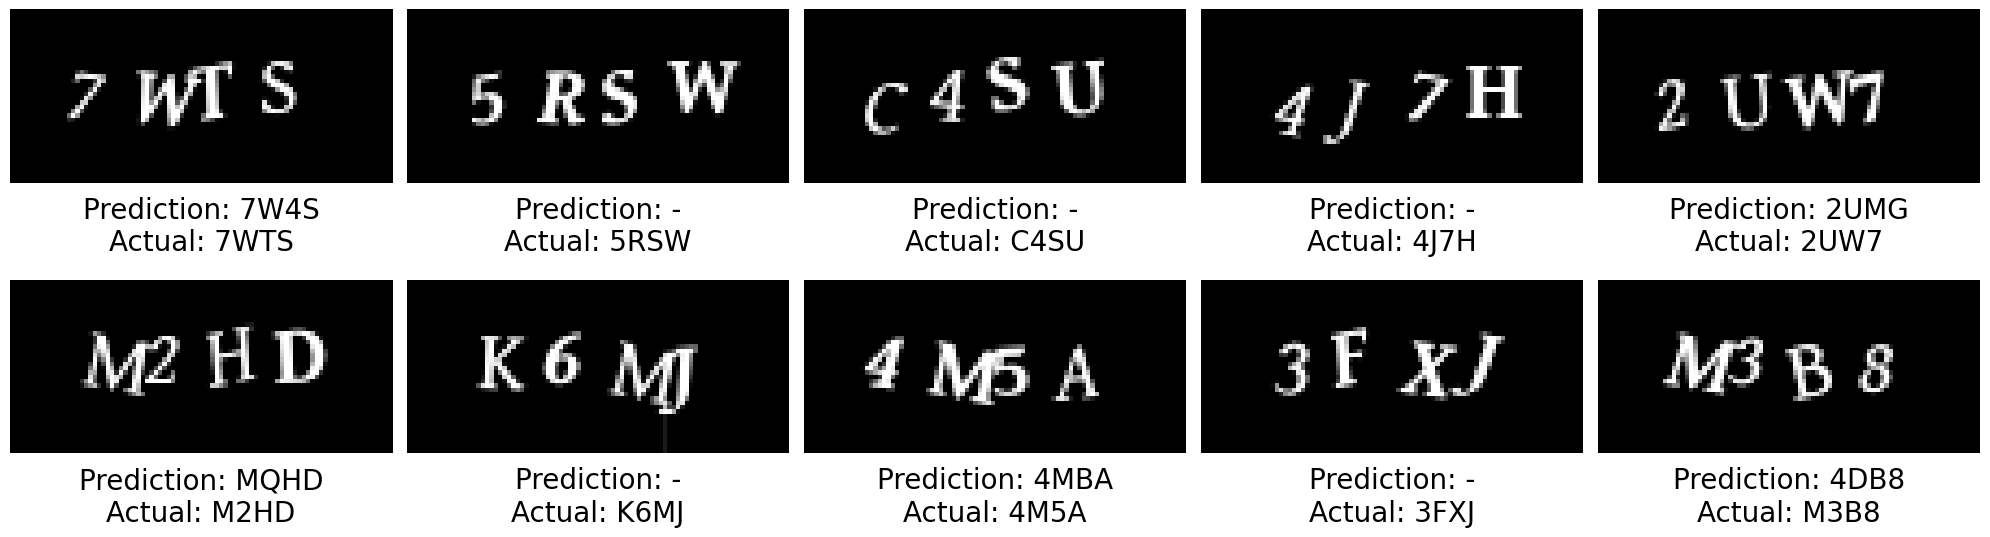

In [21]:
# Number of sample CAPTCHAs to display for each category
N_DISPLAY_SAMPLES = 10

# Total number of test CAPTCHAs
n_test = len(captcha_texts_test)
# Counter for correctly predicted CAPTCHAs
n_correct = 0

# Indices of correct predictions
correct_indices = []
# Indices of incorrect predictions
incorrect_indices = []

# Compare predictions with ground truth labels
for i, (pred_text, actual_text) in enumerate(zip(preds_test, captcha_texts_test)):
    if pred_text==actual_text:
        # This prediction is correct
        n_correct += 1
        # Collect correct prediction for visualization (up to N_DISPLAY_SAMPLES)
        if len(correct_indices)<N_DISPLAY_SAMPLES:
            correct_indices.append(i)
    else:
        # This prediction is incorrect
        # Collect incorrect prediction for visualization (up to N_DISPLAY_SAMPLES)
        if len(incorrect_indices)<N_DISPLAY_SAMPLES:
            incorrect_indices.append(i)

# Show number of total / correct predictions and accuracy
print("# of test CAPTCHAs:", n_test)
print("# correctly recognized:", n_correct)
print("Accuracy:", n_correct/n_test, "\n")

# Show sample of correct predictions
print_images(
    [captcha_images_test[i] for i in correct_indices],
    texts=[f"Correct: {captcha_texts_test[i]}" for i in correct_indices],
    n_rows=2
)

# Show sample of incorrect predictions
print_images(
    [captcha_images_test[i] for i in incorrect_indices],
    texts=[
        f"Prediction: {preds_test[i]}\nActual: {captcha_texts_test[i]}" \
        for i in incorrect_indices
    ],
    n_rows=2,
    fig_size=(20, 6),
    text_center=(0.5, -0.25)
)

## References
1. How to break a CAPTCHA system in 15 minutes with Machine Learning: https://medium.com/@ageitgey/how-to-break-a-captcha-system-in-15-minutes-with-machine-learning-dbebb035a710
2. CaptchaSolver Jupyter Notebook: https://github.com/BenjaminWegener/CaptchaSolver
3. PyTorch Official Website and Installation Instructions: https://pytorch.org
4. PyTorch Documentation: https://docs.pytorch.org/docs/stable/index.html
5. Training a Convolutional Neural Network in PyTorch: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
6. PyTorch CNN Tutorial for Beginners: https://pytorch.org/tutorials/beginner/basics/intro.html